In [31]:
import numpy as np
import matplotlib.pyplot as plt
import json

In [32]:
path = "D:\MMCSDriver\\test_data\\2024-08-14_13-15-14.json"
f2 = open(path, 'r')
info_data = json.load(f2)

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\MMCSDriver\\test_data\\2024-08-14_13-15-14.json'

In [33]:
def convert_normal_to_int16_demo(demo_i,demo_q):
    '''
    将归一化的解模因子，转换为FPGA需要的int16格式
    '''
    # Convert to int16
    demo_i_int16 = (np.array(demo_i) * 32767).astype(np.int16)
    demo_q_int16 = (np.array(demo_q) * 32767).astype(np.int16)
    return demo_i_int16,demo_q_int16

def IQ_demo_ideal(I_data_int8_offset,Q_data_int8_offset,demo1_int16,demo2_int16):
    I_sum = 0
    Q_sum = 0
    N = len(demo1_int16)
    for i in range(len(demo1_int16)):
        # I_sum += (((I_data_int8_offset[i] - 128)*(demo1_int16[i]))>>7) - (((Q_data_int8_offset[i] - 128)*(demo2_int16[i]))>>7)
        # Q_sum += (((Q_data_int8_offset[i] - 128)*(demo1_int16[i]))>>7) + (((I_data_int8_offset[i] - 128)*(demo2_int16[i]))>>7)
        I_sum += (((I_data_int8_offset[i] - 128)*(demo1_int16[i])) - ((Q_data_int8_offset[i] - 128)*(demo2_int16[i]))) >> 7
        Q_sum += (((Q_data_int8_offset[i] - 128)*(demo1_int16[i])) + ((I_data_int8_offset[i] - 128)*(demo2_int16[i]))) >> 7

    I_average = I_sum/N
    Q_average = Q_sum/N
    return I_sum, Q_sum, I_average, Q_average

In [53]:
demo_i_int16,demo_q_int16 = convert_normal_to_int16_demo(demo_i = info_data['i_demo'],demo_q= info_data['q_demo'])
I_sum_ideal = []
Q_sum_ideal = []
for i in range(3000):
    I_sum, Q_sum, I_average, Q_average = IQ_demo_ideal(I_data_int8_offset = info_data["i_raw_data"][i*1000:i*1000+1000],Q_data_int8_offset = info_data["q_raw_data"][i*1000:i*1000+1000],demo1_int16 = demo_i_int16,demo2_int16 = demo_q_int16)
    I_sum_ideal.append(I_sum)
    Q_sum_ideal.append(Q_sum)

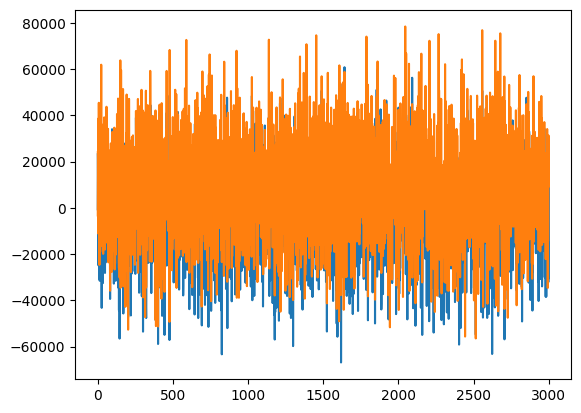

In [47]:
plt.plot(range(3000),I_sum_ideal)
plt.plot(range(3000),info_data["i_freq1_sum_fpga"])

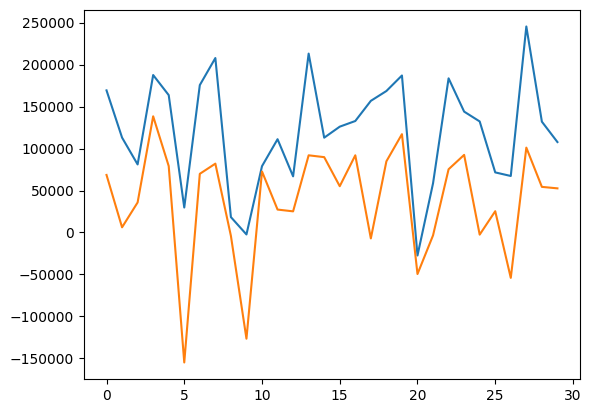

In [54]:
plt.plot(range(30),I_sum_ideal[0:30])
plt.plot(range(30),info_data["i_freq1_sum_fpga"][0:30])

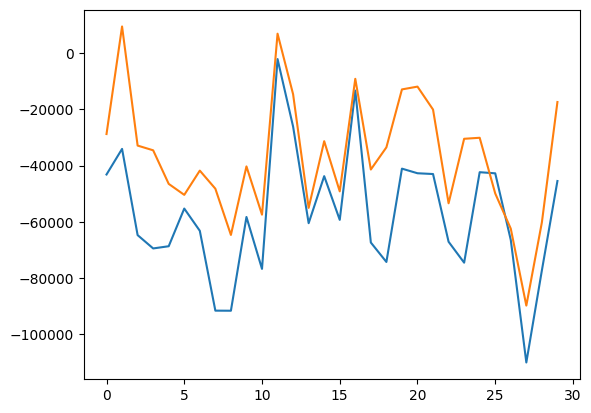

In [49]:
plt.plot(range(30),Q_sum_ideal[0:30])
plt.plot(range(30),info_data["q_freq1_sum_fpga"][0:30])

# 多个频率同时解模

In [188]:
# path = "D:\MMCSDriver\\test_data\\2024-08-14_13-54-29.json" 
path = "D:\MMCSDriver\\test_data\\2024-08-14_16-25-50.json" #with_spector
f2 = open(path, 'r')
info_data = json.load(f2)

In [189]:
len(info_data["i_raw_data"])

370000

In [190]:
demo_i_int16,demo_q_int16 = convert_normal_to_int16_demo(demo_i = info_data['i_demo1'],demo_q= info_data['q_demo1'])
I_sum_ideal1 = []
Q_sum_ideal1 = []
for i in range(37):
    I_sum, Q_sum, I_average, Q_average = IQ_demo_ideal(I_data_int8_offset = info_data["i_raw_data"][i*1000:i*1000+1000],Q_data_int8_offset = info_data["q_raw_data"][i*1000:i*1000+1000],demo1_int16 = demo_i_int16,demo2_int16 = demo_q_int16)
    I_sum_ideal1.append(I_sum)
    Q_sum_ideal1.append(Q_sum)

demo_i_int16,demo_q_int16 = convert_normal_to_int16_demo(demo_i = info_data['i_demo2'],demo_q= info_data['q_demo2'])
I_sum_ideal2 = []
Q_sum_ideal2 = []
for i in range(37):
    I_sum, Q_sum, I_average, Q_average = IQ_demo_ideal(I_data_int8_offset = info_data["i_raw_data"][i*1000:i*1000+1000],Q_data_int8_offset = info_data["q_raw_data"][i*1000:i*1000+1000],demo1_int16 = demo_i_int16,demo2_int16 = demo_q_int16)
    I_sum_ideal2.append(I_sum)
    Q_sum_ideal2.append(Q_sum)

<Figure size 640x480 with 0 Axes>

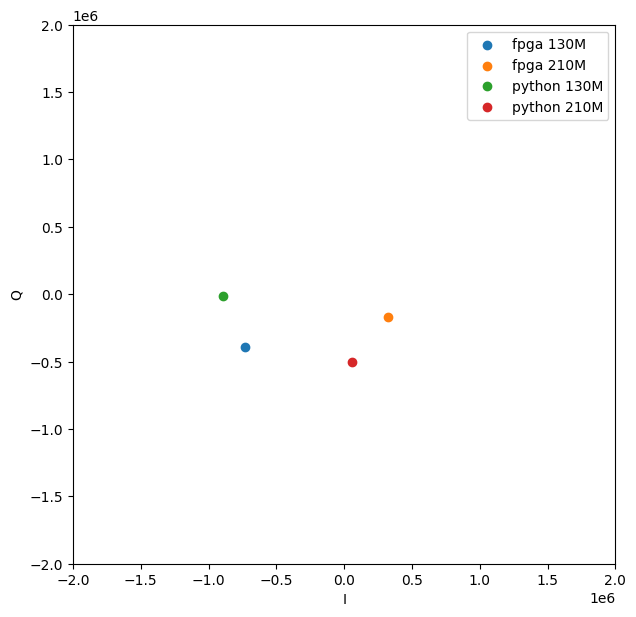

In [85]:
num = 1
plt.clf()
plt.figure(figsize=(7, 7))
#plt.figure(dpi=600)
plt.scatter(info_data["i_freq1_sum_fpga"][:num], info_data["q_freq1_sum_fpga"][:num],label = 'fpga 130M')
plt.scatter(info_data["i_freq2_sum_fpga"][:num], info_data["q_freq2_sum_fpga"][:num],label = "fpga 210M")
plt.scatter(I_sum_ideal1[:num],Q_sum_ideal1[:num] ,label = 'python 130M')
plt.scatter(I_sum_ideal2[:num],Q_sum_ideal2[:num] ,label = 'python 210M')
#plt.scatter(i_freq1_sum_fpga, q_freq1_sum_fpga)
#plt.colorbar(label = 'phase (degree)') 
plt.legend()
plt.xlim(-2000_000,2000_000)
plt.ylim(-2000_000,2000_000)
plt.xlabel('I')
plt.ylabel('Q')
# plt.title(title+''+timestamp)
# if (save_data):
#     plt.savefig(path+f'{timestamp}_{title}.svg',format = 'svg')  # 保存图像 
#     plt.savefig(path+f'{timestamp}_{title}.png')  # 保存图像 
plt.show(block=True)

# 对比是否有干扰

In [34]:
path = "D:\MMCSDriver_public_git\\test_data\\2024-08-16_12-51-52.json" #with_spectator
f2 = open(path, 'r')
info_data = json.load(f2)

demo_i_int16,demo_q_int16 = convert_normal_to_int16_demo(demo_i = info_data['i_demo1'],demo_q= info_data['q_demo1'])
# #模拟解模因子有delay的情况
# #拼接demo_i_int16[:4]  demo_i_int16[:-4]
# demo_i_int16 = np.append(demo_i_int16[:16],demo_i_int16[:-16])
# demo_q_int16 = np.append(demo_q_int16[:16],demo_q_int16[:-16])

I_sum_ideal1 = []
Q_sum_ideal1 = []
for i in range(3700):
    I_sum, Q_sum, I_average, Q_average = IQ_demo_ideal(I_data_int8_offset = info_data["i_raw_data"][i*1000:i*1000+1000],Q_data_int8_offset = info_data["q_raw_data"][i*1000:i*1000+1000],demo1_int16 = demo_i_int16,demo2_int16 = demo_q_int16)
    I_sum_ideal1.append(I_sum)
    Q_sum_ideal1.append(Q_sum)

# demo_i_int16,demo_q_int16 = convert_normal_to_int16_demo(demo_i = info_data['i_demo2'],demo_q= info_data['q_demo2'])
# I_sum_ideal2 = []
# Q_sum_ideal2 = []
# for i in range(3700):
#     I_sum, Q_sum, I_average, Q_average = IQ_demo_ideal(I_data_int8_offset = info_data["i_raw_data"][i*1000:i*1000+1000],Q_data_int8_offset = info_data["q_raw_data"][i*1000:i*1000+1000],demo1_int16 = demo_i_int16,demo2_int16 = demo_q_int16)
#     I_sum_ideal2.append(I_sum)
#     Q_sum_ideal2.append(Q_sum)

I_sum_ideal1_with_spectator = I_sum_ideal1
Q_sum_ideal1_with_spectator = Q_sum_ideal1
I_sum_fpga1_with_spectator = info_data["i_freq1_sum_fpga"]
Q_sum_fpga1_with_spectator = info_data["q_freq1_sum_fpga"]

In [40]:
Q_sum_ideal1_with_spectator[:5]

array([4571823.31, 3637494.01, 2588952.23, 1460794.65,  282436.83])

In [41]:
Q_sum_fpga1_with_spectator[:5]

array([4571823.31, 3637494.01, 2588952.23, 1460794.65,  282436.83])

In [39]:
I_sum_ideal1_with_spectator = np.mean(np.array(I_sum_ideal1_with_spectator).reshape(37,100),1)
Q_sum_ideal1_with_spectator = np.mean(np.array(Q_sum_ideal1_with_spectator).reshape(37,100),1)
I_sum_fpga1_with_spectator = np.mean(np.array(I_sum_fpga1_with_spectator).reshape(37,100),1)
Q_sum_fpga1_with_spectator = np.mean(np.array(Q_sum_fpga1_with_spectator).reshape(37,100),1)

In [42]:
path = "D:\MMCSDriver_public_git\\test_data\\2024-08-16_12-52-31.json" #without_spectator
f2 = open(path, 'r')
info_data = json.load(f2)

demo_i_int16,demo_q_int16 = convert_normal_to_int16_demo(demo_i = info_data['i_demo1'],demo_q= info_data['q_demo1'])

# #模拟解模因子有delay的情况
# #拼接demo_i_int16[:4]  demo_i_int16[:-4]
# demo_i_int16 = np.append(demo_i_int16[:16],demo_i_int16[:-16])
# demo_q_int16 = np.append(demo_q_int16[:16],demo_q_int16[:-16])

I_sum_ideal1 = []
Q_sum_ideal1 = []
for i in range(3700):
    I_sum, Q_sum, I_average, Q_average = IQ_demo_ideal(I_data_int8_offset = info_data["i_raw_data"][i*1000:i*1000+1000],Q_data_int8_offset = info_data["q_raw_data"][i*1000:i*1000+1000],demo1_int16 = demo_i_int16,demo2_int16 = demo_q_int16)
    I_sum_ideal1.append(I_sum)
    Q_sum_ideal1.append(Q_sum)

# demo_i_int16,demo_q_int16 = convert_normal_to_int16_demo(demo_i = info_data['i_demo2'],demo_q= info_data['q_demo2'])
# I_sum_ideal2 = []
# Q_sum_ideal2 = []
# for i in range(3700):
#     I_sum, Q_sum, I_average, Q_average = IQ_demo_ideal(I_data_int8_offset = info_data["i_raw_data"][i*1000:i*1000+1000],Q_data_int8_offset = info_data["q_raw_data"][i*1000:i*1000+1000],demo1_int16 = demo_i_int16,demo2_int16 = demo_q_int16)
#     I_sum_ideal2.append(I_sum)
#     Q_sum_ideal2.append(Q_sum)

I_sum_ideal1_without_spectator = I_sum_ideal1
Q_sum_ideal1_without_spectator = Q_sum_ideal1
I_sum_fpga1_without_spectator = info_data["i_freq1_sum_fpga"]
Q_sum_fpga1_without_spectator = info_data["q_freq1_sum_fpga"]

In [43]:
I_sum_ideal1_without_spectator = np.mean(np.array(I_sum_ideal1_without_spectator).reshape(37,100),1)
Q_sum_ideal1_without_spectator = np.mean(np.array(Q_sum_ideal1_without_spectator).reshape(37,100),1)
I_sum_fpga1_without_spectator = np.mean(np.array(I_sum_fpga1_without_spectator).reshape(37,100),1)
Q_sum_fpga1_without_spectator = np.mean(np.array(Q_sum_fpga1_without_spectator).reshape(37,100),1)


<Figure size 640x480 with 0 Axes>

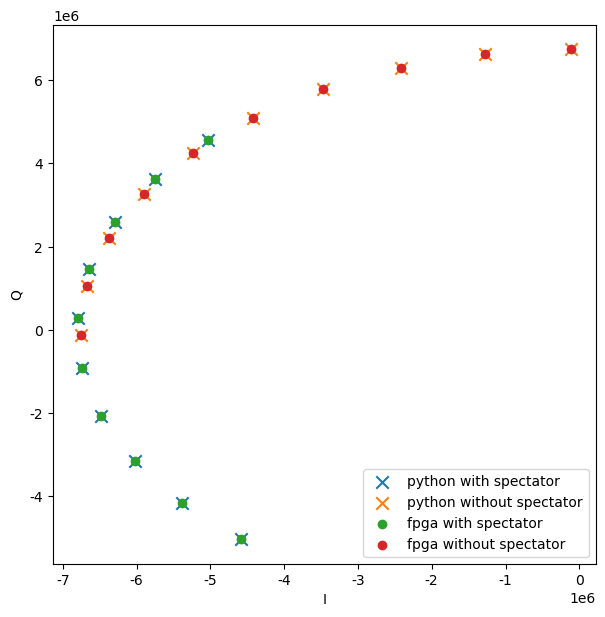

In [53]:
num = 10
plt.clf()
plt.figure(figsize=(7, 7))
#plt.figure(dpi=600)
plt.scatter(I_sum_ideal1_with_spectator[:num], Q_sum_ideal1_with_spectator[:num],marker='x',s=80,label = 'python with spectator')
plt.scatter(I_sum_ideal1_without_spectator[:num], Q_sum_ideal1_without_spectator[:num],marker="x",s=80,label = 'python without spectator')
plt.scatter(I_sum_fpga1_with_spectator[:num], Q_sum_fpga1_with_spectator[:num],label = 'fpga with spectator')
plt.scatter(I_sum_fpga1_without_spectator[:num], Q_sum_fpga1_without_spectator[:num],label = 'fpga without spectator')

#plt.scatter(i_freq1_sum_fpga, q_freq1_sum_fpga)
#plt.colorbar(label = 'phase (degree)') 
plt.legend()
# plt.xlim(-500_000,200_000)
# plt.ylim(-200_000,500_000)
plt.xlabel('I')
plt.ylabel('Q')
# plt.title(title+''+timestamp)
# if (save_data):
#     plt.savefig(path+f'{timestamp}_{title}.svg',format = 'svg')  # 保存图像 
#     plt.savefig(path+f'{timestamp}_{title}.png')  # 保存图像 
plt.show(block=True)

In [35]:
def gen_normalized_demodulation_factor(IF_freq = 100e6, demo_length = 1000,demo_phase = 0, demod_width = 0):
    '''
    产生归一化的解模因子,demo_i[t] = cos(-wt+demo_phi),demo_q[t] = cos(-wt+demo_phi)
    generate demodulation factor list for single-frequency wave
    For example, for each element in input wave list
        wave_i[t] = cos(wt+phi)
        wave_q[t] = sin(wt+phi)
        then, wave_input_complex[t] = cos(wt+phi) + j sin(wt+phi) = exp(wt+phi)
        Set demo[t] = exp(-wt)
        then, IQ_complex[t] = wave_input_complex * demo = exp(wt+phi) * exp(-wt) = exp(phi)
        I[t] = real(exp(phi)) = cos(phi)
        Q[t] = imag(exp(phi)) = sin(phi)
    Xunadong Sun 2023/10/21
    Arg:
        IF_freq: Demo frequency(Hz), such as 100e6
        demo_length: the number of demo factor points. EXP, demo_length=1000 means 1us
        demo_phase: (degree unit, such as 90, 180...) Demo = exp(-wt+demo_phase)
    
    Return:
        demo_i: a list, cos(-IF * 2pi *t + demophase)  (each data is within [-1,+1])
        demo_q: a list, sine(-IF * 2pi *t + demophase) 
    '''
    adc_sample_rate = 1e9
    dt = 1 / adc_sample_rate
    t_list = np.linspace(0, (demo_length-1)*dt, demo_length)

    At = np.ones(demo_length)
    if demod_width:
        half_width = int(demod_width/2)
        At[0:half_width] = np.sin(  np.linspace(0, 1, half_width) * np.pi/2) 
        At[-half_width:] = np.cos(  np.linspace(0, 1, half_width) * np.pi/2) 
    
    #generate demo factor
    demo_i = At*np.cos(- IF_freq * 2 * np.pi * t_list + np.deg2rad(demo_phase))
    demo_q = At*np.sin(- IF_freq * 2 * np.pi * t_list + np.deg2rad(demo_phase))

    return demo_i, demo_q

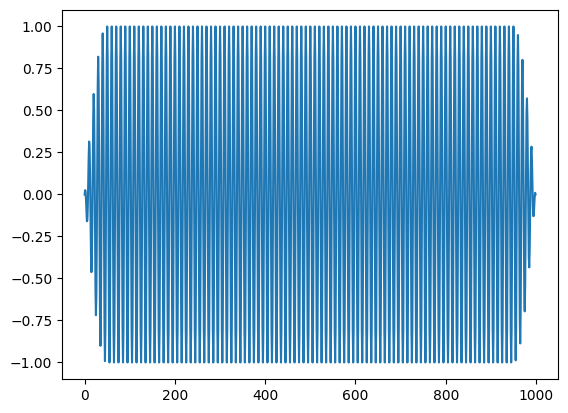

In [260]:
demo_i, demo_q = gen_normalized_demodulation_factor(100e6,1000,0,100)
plt.plot(demo_i)

In [6]:
I_data_int8_offset = 229
Q_data_int8_offset = 228
demo1_int16 = 273
demo2_int16 = 257


I_sum = (((I_data_int8_offset - 128)*(demo1_int16)) - ((Q_data_int8_offset - 128)*(demo2_int16)))>>7
Q_sum = (((Q_data_int8_offset - 128)*(demo1_int16)) + ((I_data_int8_offset - 128)*(demo2_int16)))>>7
print(I_sum,Q_sum)

14 416


# 位操作尝试

In [8]:
import numpy as np

In [29]:
ram_data = np.array([32767,22430,-2057],dtype=np.int16)
ram_data = np.array(ram_data).astype(np.uint32)
address = np.array([0,1,2],dtype=np.uint32)
address = address << 16
send_data = address + (ram_data &0x0000FFFF)
# np.array(send_data,dtype=np.uint32)

In [30]:
send_data


array([ 32767,  87966, 194551], dtype=uint32)